# Two crucial figures: prediction quality and adversarial robustness

This notebook implements the two agreed paper figures. It separates **measured**, **unverified**, and **missing** results; performs byte/token round-trip checks where possible; and never replaces a missing serialized size with an entropy estimate. The oracle in Figure 1 is an entropy-only reference, not an operational codec.

Figure 1 uses only non-overlapping text8 blocks. Qwen and Anti-Qwen use identical token sequences and the same integer-frequency arithmetic coder. Anti-Qwen is defined precisely as $\operatorname{softmax}(-z_{\rm Qwen})$. Figure 2 counts complete streams for token IDs, FSST, and Brotli. Qwen model weights and the global Qwen token table are treated as shared decoder state.

In [1]:
from pathlib import Path
import json, math, os, random, sys

START = Path.cwd().resolve()
ROOT = next(candidate for candidate in (START, *START.parents) if (candidate / 'pyproject.toml').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoModelForCausalLM, AutoTokenizer

from evaluation.crucial_figures import (
    benchmark_brotli, benchmark_fsst, benchmark_tokenization,
    find_repo_root, parse_predictive_payload, plot_compressor_bars,
    plot_surprisal_scatter, read_json, serialize_predictive_payload,
    validate_bar_results,
)
from src.encoding import LLMCompressor, LLMDecompressor

assert find_repo_root() == ROOT
FIGURE_DIR = ROOT / 'artifacts/figures/neurips/crucial'
RESULT_DIR = ROOT / 'artifacts/runs/crucial-figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = 'Qwen/Qwen2.5-0.5B'
TEXT8 = ROOT / 'data/text8'
FSST_COMMIT = 'e638d4cf8c26129d73c242a4127b42b975de5b63'
FSST_EXECUTABLE = Path(os.environ.get('FSST_EXECUTABLE', '/tmp/compression-economics-fsst/build/fsst'))

mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 8.5,
    'axes.titlesize': 9.5, 'axes.titleweight': 'bold',
    'axes.labelsize': 8.5, 'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5, 'legend.fontsize': 7.2,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.03,
})

def save_figure(fig, stem):
    png = FIGURE_DIR / f"{stem}.png"
    fig.savefig(png, dpi=300)
    print("Saved", png.relative_to(ROOT))

assert TEXT8.is_file() and TEXT8.stat().st_size == 100_000_000
print('Repository:', ROOT)
print('Torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
print('FSST:', FSST_EXECUTABLE if FSST_EXECUTABLE.is_file() else 'not configured')

Repository: /home/neubauer/src/compression-economics
Torch: 2.10.0+cu128 | CUDA: False
FSST: /tmp/compression-economics-fsst/build/fsst


## Figure 1 — prediction quality versus realized compression on text8

The unit of observation is an independently coded, non-overlapping 64-token text8 block. The x-axis is the unquantized model NLL in bits per predicted token. The y-axis is the byte length of a concrete predictive stream divided by the block's decoded UTF-8 bytes. Its 28-byte header records format/model code, seed token, token count, raw byte count, and arithmetic payload length; model weights remain shared.

The arithmetic decoder is checked against every encoded token. Because the current frequency table reserves one count for every vocabulary item, very small Anti-Qwen probabilities may be clipped to a much shorter code than their model NLL suggests.

In [2]:
SCATTER_CACHE = RESULT_DIR / 'text8_model_scatter.csv'
N_BLOCKS = 12
TOKENS_PER_BLOCK = 64
RUN_FRESH_MODEL_SCORING = not SCATTER_CACHE.exists()

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, cache_dir=ROOT / '.cache', local_files_only=True
)
vocab_size = tokenizer.vocab_size
assert vocab_size == 151_643

def text8_token_prefix(limit):
    text = ''
    chunk_size = max(65_536, limit * 8)
    with TEXT8.open('r', encoding='utf-8', newline='') as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                raise ValueError(f'text8 contains fewer than {limit} tokens')
            text += chunk
            tokens = tokenizer.encode(text, add_special_tokens=False)
            if len(tokens) >= limit:
                return tokens[:limit]

def score_distribution(logits, targets, sign, model_code, raw, seed):
    compressor = LLMCompressor()
    surprisal = 0.0
    for row, target in zip(logits, targets):
        signed = sign * row.double()
        surprisal += float((torch.logsumexp(signed, 0) - signed[target]) / math.log(2))
        probabilities = torch.softmax(signed, 0).numpy()
        compressor.next_token(int(target), probabilities)
    bits = compressor.compress()
    stream = serialize_predictive_payload(
        bits, seed_token=int(seed), model_code=model_code,
        token_count=len(targets) + 1, raw_size_bytes=len(raw),
    )
    parsed = parse_predictive_payload(stream)
    decoder = LLMDecompressor(parsed['bits'])
    reconstructed = [int(seed)]
    for row in logits:
        probabilities = torch.softmax(sign * row.double(), 0).numpy()
        reconstructed.append(decoder.decompress(probabilities))
    assert reconstructed == [int(seed), *map(int, targets)]
    return {
        'surprisal_bits_per_token': surprisal / len(targets),
        'arithmetic_payload_bits': len(bits),
        'serialized_size_bytes': len(stream),
        'raw_size_bytes': len(raw),
        'relative_size_percent': 100 * len(stream) / len(raw),
        'round_trip': True,
    }

if RUN_FRESH_MODEL_SCORING:
    all_tokens = text8_token_prefix(N_BLOCKS * TOKENS_PER_BLOCK)
    assert len(all_tokens) == N_BLOCKS * TOKENS_PER_BLOCK
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, cache_dir=ROOT / '.cache', local_files_only=True, torch_dtype='auto'
    ).eval()
    rows = []
    with torch.inference_mode():
        for block_index in range(N_BLOCKS):
            block = all_tokens[block_index*TOKENS_PER_BLOCK:(block_index+1)*TOKENS_PER_BLOCK]
            raw = tokenizer.decode(
                block, skip_special_tokens=False, clean_up_tokenization_spaces=False
            ).encode('utf-8')
            assert tokenizer.encode(raw.decode('utf-8'), add_special_tokens=False) == block
            input_ids = torch.tensor([block])
            logits = model(input_ids=input_ids, use_cache=False).logits[0, :-1, :vocab_size].cpu()
            targets = block[1:]
            for name, sign, code in [('Qwen2.5-0.5B', 1, 1), ('Anti-Qwen', -1, 2)]:
                result = score_distribution(logits, targets, sign, code, raw, block[0])
                rows.append({'block': block_index, 'model': name, **result})
            print(f'Finished block {block_index + 1}/{N_BLOCKS}')
    scatter = pd.DataFrame(rows)
    scatter.to_csv(SCATTER_CACHE, index=False)
    del model
else:
    scatter = pd.read_csv(SCATTER_CACHE)

assert len(scatter) == 2 * N_BLOCKS
assert scatter['round_trip'].all()
display(scatter.groupby('model').agg(
    blocks=('block', 'count'),
    surprisal_mean=('surprisal_bits_per_token', 'mean'),
    relative_size_mean=('relative_size_percent', 'mean'),
    relative_size_std=('relative_size_percent', 'std'),
).round(3))

,blocks,surprisal_mean,relative_size_mean,relative_size_std
model,,,,
Anti-Qwen,12,44.955,49.247,5.030
Qwen2.5-0.5B,12,6.120,24.570,2.819


Saved artifacts/figures/neurips/crucial/prediction_quality_vs_realized_compression.png


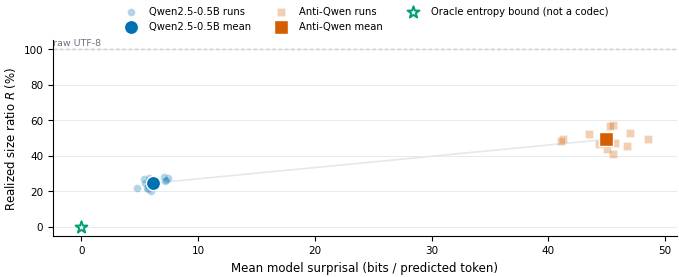

In [3]:
fig, ax = plot_surprisal_scatter(scatter)
save_figure(fig, 'prediction_quality_vs_realized_compression')
plt.show()

### Figure 1 interpretation

The translucent points are individual block runs; the larger solid markers are model means, and the line connects only those means. Qwen and Anti-Qwen change only the probability distribution. The oracle star at $(0,0)$ is the unattainable entropy limit and deliberately excludes framing. If Anti-Qwen's NLL grows much faster than its realized size, the cause is the arithmetic coder's finite-frequency floor—not unexpectedly good prediction.

## Figure 2 — End-to-end compression across natural and adversarial inputs

This section builds an audit table before plotting. `Qwen tokenization only` stores every token as a fixed-width 18-bit ID and includes a 24-byte stream header; the shared Qwen token table is excluded. FSST uses the official CWI CLI's own block format, which includes its exported symbol table and framing. Brotli is the complete quality-11 stream. Every one of these streams must decode byte-for-byte.

The official FSST source is pinned to commit `e638d4cf8c26129d73c242a4127b42b975de5b63`. Set `FSST_EXECUTABLE` to its compiled `fsst` binary. Results from the current repository are intentionally marked missing or unverified when only an ideal/payload length exists.

In [4]:
DATASET_ORDER = [
    'text8', 'random text', 'token-level adversary',
    'byte-aware adversary', 'one-byte adversary',
]

def decoded_bytes(token_ids):
    return tokenizer.decode(
        token_ids, skip_special_tokens=False, clean_up_tokenization_spaces=False
    ).encode('utf-8')

datasets = {}
text8_tokens = text8_token_prefix(100_000)
datasets['text8'] = {
    'data': decoded_bytes(text8_tokens), 'token_ids': text8_tokens,
    'provenance': 'first 100,000 Qwen tokens from data/text8',
}
rng = random.Random(0)
random_data = ''.join(chr(rng.randrange(32, 127)) for _ in range(65_536)).encode('utf-8')
random_tokens = tokenizer.encode(random_data.decode('utf-8'), add_special_tokens=False)
datasets['random text'] = {
    'data': random_data, 'token_ids': random_tokens,
    'provenance': '65,536 seeded printable-ASCII bytes',
}

token_adv_dir = ROOT / 'artifacts/runs/paper-evaluation/full_vocab_n10000/full'
token_adv_tokens = read_json(token_adv_dir / 'run_00.tokens.json')
token_adv_data = (token_adv_dir / 'run_00.txt').read_bytes()
assert decoded_bytes(token_adv_tokens) == token_adv_data
datasets['token-level adversary'] = {
    'data': token_adv_data, 'token_ids': token_adv_tokens,
    'provenance': '10,000-token greedy minimum-probability run 0',
}

# A 32-token smoke test is not promoted to a paper result.
byte_aware_candidates = [
    ROOT / 'artifacts/runs/paper-evaluation/full_vocab_n10000/surprisal-per-byte_run_00.txt',
    ROOT / 'artifacts/runs/compression-attacks/qwen_05b_n10000/surprisal-per-byte_run_00.txt',
]
byte_aware_path = next((path for path in byte_aware_candidates if path.is_file()), None)
if byte_aware_path is not None:
    byte_tokens = read_json(byte_aware_path.with_suffix('.tokens.json'))
    byte_data = byte_aware_path.read_bytes()
    assert decoded_bytes(byte_tokens) == byte_data
    datasets['byte-aware adversary'] = {
        'data': byte_data, 'token_ids': byte_tokens,
        'provenance': str(byte_aware_path.relative_to(ROOT)),
    }

one_dir = ROOT / 'artifacts/runs/adversarial/qwen_05b_ascii_bytes_n1000/full'
one_tokens = read_json(one_dir / 'run_00.tokens.json')
one_data = (one_dir / 'run_00.txt').read_bytes()
assert decoded_bytes(one_tokens) == one_data
datasets['one-byte adversary'] = {
    'data': one_data, 'token_ids': one_tokens,
    'provenance': '1,000-token canonical one-byte run',
}

display(pd.DataFrame([
    {'dataset': name, 'raw_size_bytes': len(item['data']), 'tokens': len(item['token_ids']), 'provenance': item['provenance']}
    for name, item in datasets.items()
]))

Token indices sequence length is longer than the specified maximum sequence length for this model (151538 > 131072). Running this sequence through the model will result in indexing errors


,dataset,raw_size_bytes,tokens,provenance
0,text8,532654,100000,"first 100,000 Qwen tokens from data/text8"
1,random text,65536,50155,"65,536 seeded printable-ASCII bytes"
2,token-level adversary,71159,10000,"10,000-token greedy minimum-probability run 0"
3,one-byte adversary,1000,1000,"1,000-token canonical one-byte run"


In [5]:
rows = []
for dataset in DATASET_ORDER:
    item = datasets.get(dataset)
    if item is None:
        for codec in ['Qwen + AC', 'Qwen token IDs', 'FSST', 'Brotli q11']:
            rows.append({'dataset': dataset, 'codec': codec, 'status': 'missing', 'round_trip': pd.NA, 'note': 'long byte-aware run is absent'})
        continue
    data, ids = item['data'], item['token_ids']
    token_result = benchmark_tokenization(data, ids, tokenizer=tokenizer, vocab_size=vocab_size)
    rows.append({'dataset': dataset, 'status': 'measured', 'note': 'shared Qwen token table excluded', **token_result})
    brotli_result = benchmark_brotli(data, quality=11)
    rows.append({'dataset': dataset, 'status': 'measured', 'note': 'complete Brotli stream', **brotli_result})
    if FSST_EXECUTABLE.is_file():
        fsst_result = benchmark_fsst(data, executable=FSST_EXECUTABLE)
        rows.append({'dataset': dataset, 'status': 'measured', 'note': f'official FSST CLI at {FSST_COMMIT}', **fsst_result})
    else:
        rows.append({'dataset': dataset, 'codec': 'FSST', 'status': 'missing', 'round_trip': pd.NA, 'raw_size_bytes': len(data), 'note': 'set FSST_EXECUTABLE'})

    if dataset == 'one-byte adversary':
        verification = read_json(one_dir / 'compression_verification.json')
        round_trip = all(verification[key] for key in [
            'token_round_trip', 'byte_round_trip',
            'serialized_artifact_token_round_trip', 'serialized_artifact_byte_round_trip',
        ])
        rows.append({
            'dataset': dataset, 'codec': 'Qwen + AC', 'status': 'measured',
            'raw_size_bytes': len(data),
            'serialized_size_bytes': verification['serialized_file_size_bytes'],
            'round_trip': round_trip, 'note': 'stored serialized file; verified token and byte round trip',
        })
    elif dataset == 'text8':
        path = ROOT / 'artifacts/runs/typical_text8/qwen_05b_n100000/full/compression_data.bin'
        rows.append({
            'dataset': dataset, 'codec': 'Qwen + AC', 'status': 'unverified',
            'raw_size_bytes': len(data), 'serialized_size_bytes': path.stat().st_size,
            'round_trip': False, 'note': 'serialized artifact exists but no matching round-trip record',
        })
    else:
        rows.append({
            'dataset': dataset, 'codec': 'Qwen + AC', 'status': 'missing',
            'raw_size_bytes': len(data), 'round_trip': pd.NA,
            'note': 'no complete serialized and round-trip-verified Qwen artifact',
        })

bar_audit = pd.DataFrame(rows)
bar_audit['relative_size_percent'] = 100 * bar_audit['serialized_size_bytes'] / bar_audit['raw_size_bytes']
bar_audit.to_csv(RESULT_DIR / 'compressor_robustness_audit.csv', index=False)
display(bar_audit.sort_values(['dataset', 'codec'])[[
    'dataset', 'codec', 'status', 'raw_size_bytes', 'serialized_size_bytes',
    'relative_size_percent', 'round_trip', 'note',
]].round(3))

,dataset,codec,status,raw_size_bytes,serialized_size_bytes,relative_size_percent,round_trip,note
15,byte-aware adversary,Brotli q11,missing,NaN,NaN,NaN,<NA>,long byte-aware run is absent
14,byte-aware adversary,FSST,missing,NaN,NaN,NaN,<NA>,long byte-aware run is absent
12,byte-aware adversary,Qwen + AC,missing,NaN,NaN,NaN,<NA>,long byte-aware run is absent
13,byte-aware adversary,Qwen token IDs,missing,NaN,NaN,NaN,<NA>,long byte-aware run is absent
17,one-byte adversary,Brotli q11,measured,1000.0,858.0,85.800,True,complete Brotli stream
18,one-byte adversary,FSST,measured,1000.0,1144.0,114.400,True,official FSST CLI at e638d4cf8c26129d73c242a41...
19,one-byte adversary,Qwen + AC,measured,1000.0,1552.0,155.200,True,stored serialized file; verified token and byt...
16,one-byte adversary,Qwen token IDs,measured,1000.0,2274.0,227.400,True,shared Qwen token table excluded
5,random text,Brotli q11,measured,65536.0,54412.0,83.026,True,complete Brotli stream
6,random text,FSST,measured,65536.0,64469.0,98.372,True,official FSST CLI at e638d4cf8c26129d73c242a41...


,check,passed,detail
0,all 20 codec/dataset cells measured,False,7 cells remain
1,raw byte sizes within 10%,False,"{'text8': 532654, 'random text': 65536, 'token..."
2,paper-ready export,False,final PNG is gated


,missing_dataset,missing_codec
0,byte-aware adversary,Brotli q11
1,byte-aware adversary,FSST
2,byte-aware adversary,Qwen + AC
3,byte-aware adversary,Qwen token IDs
4,random text,Qwen + AC
5,text8,Qwen + AC
6,token-level adversary,Qwen + AC


Saved artifacts/figures/neurips/crucial/end_to_end_compressor_robustness_preview.png


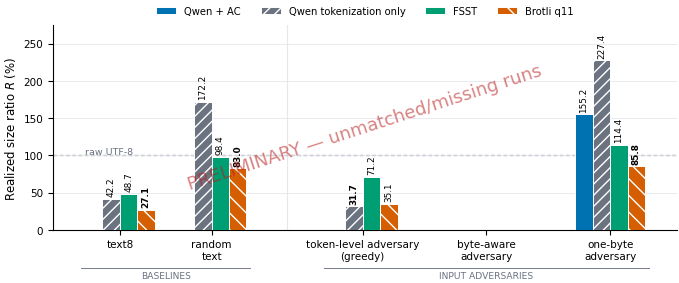

In [6]:
expected = pd.MultiIndex.from_product([
    DATASET_ORDER, ['Qwen + AC', 'Qwen token IDs', 'FSST', 'Brotli q11']
], names=['dataset', 'codec'])
measured = validate_bar_results(bar_audit, DATASET_ORDER)
observed = pd.MultiIndex.from_frame(measured[['dataset', 'codec']])
missing_pairs = expected.difference(observed)
raw_sizes = pd.Series({name: len(item['data']) for name, item in datasets.items()})
comparable_sizes = len(raw_sizes) == len(DATASET_ORDER) and raw_sizes.max() / raw_sizes.min() <= 1.10
paper_ready = len(missing_pairs) == 0 and comparable_sizes

readiness = pd.DataFrame({
    'check': ['all 20 codec/dataset cells measured', 'raw byte sizes within 10%', 'paper-ready export'],
    'passed': [len(missing_pairs) == 0, comparable_sizes, paper_ready],
    'detail': [f'{len(missing_pairs)} cells remain', raw_sizes.to_dict(), 'final PNG is gated'],
})
display(readiness)
if len(missing_pairs):
    display(pd.DataFrame(missing_pairs.tolist(), columns=['missing_dataset', 'missing_codec']))

fig, ax = plot_compressor_bars(bar_audit, DATASET_ORDER)
if paper_ready:
    save_figure(fig, 'end_to_end_compressor_robustness')
else:
    ax.text(
        0.5, 0.5, 'PRELIMINARY — unmatched/missing runs', transform=ax.transAxes,
        ha='center', va='center', fontsize=13, color='#B91C1C', alpha=0.55, rotation=18,
    )
    save_figure(fig, 'end_to_end_compressor_robustness_preview')
plt.show()

## Preliminary paper-evaluation sweep

This live view reads the atomically written `results.json` checkpoints from the 10,000-byte printable-ASCII and ASCII-byte sweeps. It includes only conditions already persisted by the running experiment. Small points are individual seeds; bars and error bars are the mean and sample standard deviation. **Model estimate** is the realized model cross-entropy divided by raw UTF-8 size, while **AC payload** is the finalized arithmetic payload divided by raw UTF-8 size. The dashed line is the uncompressed UTF-8 size.

![Current preliminary sweep](../../../artifacts/figures/neurips/crucial/preliminary_paper_evaluation_sweep.png)


In [ ]:
SWEEP_ROOT = ROOT / 'artifacts/runs/paper-evaluation'
SWEEP_SPECS = [
    ('Printable ASCII', SWEEP_ROOT / 'printable-ascii_n10000/results.json'),
    ('ASCII bytes', SWEEP_ROOT / 'ascii-bytes_n10000/results.json'),
]
CONDITION_ORDER = [
    'ordinary-text8', 'random-printable-utf8', 'random-token',
    'min-probability', 'surprisal-per-byte',
]
CONDITION_LABELS = {
    'ordinary-text8': 'Ordinary\ntext8',
    'random-printable-utf8': 'Random printable\nUTF-8',
    'random-token': 'Random\ntoken',
    'min-probability': 'Minimum\nprobability',
    'surprisal-per-byte': 'Surprisal\nper byte',
}

records = []
checkpoint_metadata = []
for alphabet, path in SWEEP_SPECS:
    if not path.is_file():
        continue
    payload = read_json(path)
    metadata = payload['metadata']
    checkpoint_metadata.append({
        'alphabet': alphabet,
        'tokens_per_seed': metadata['total_length'],
        'checkpoint': str(path.relative_to(ROOT)),
    })
    for run in payload['runs']:
        records.append({
            'alphabet': alphabet,
            'condition': run['condition'],
            'seed': run['run_index'],
            'model_estimate_percent': 100 * run['model_entropy_ratio'],
            'ac_payload_percent': 100 * run['arithmetic_payload_ratio'],
        })

if not records:
    raise FileNotFoundError(f'No completed sweep checkpoints under {SWEEP_ROOT}')

sweep = pd.DataFrame(records)
observed_conditions = list(dict.fromkeys(sweep['condition']))
condition_rank = {name: index for index, name in enumerate(CONDITION_ORDER)}
observed_conditions.sort(key=lambda name: (condition_rank.get(name, len(CONDITION_ORDER)), name))
summary = (
    sweep.groupby(['alphabet', 'condition'], sort=False)
    .agg(
        seeds=('seed', 'count'),
        model_mean=('model_estimate_percent', 'mean'),
        model_std=('model_estimate_percent', 'std'),
        ac_mean=('ac_payload_percent', 'mean'),
        ac_std=('ac_payload_percent', 'std'),
    )
    .reset_index()
    .fillna({'model_std': 0.0, 'ac_std': 0.0})
)
display(pd.DataFrame(checkpoint_metadata))
display(summary.round(2))

fig, axes = plt.subplots(1, len(SWEEP_SPECS), figsize=(7.05, 3.35), sharey=True)
axes = np.atleast_1d(axes)
bar_width = 0.34
series = [
    ('model_estimate_percent', 'model_mean', 'model_std', 'Model estimate', '#2563EB'),
    ('ac_payload_percent', 'ac_mean', 'ac_std', 'AC payload', '#EA580C'),
]
for ax, (alphabet, _) in zip(axes, SWEEP_SPECS):
    alphabet_summary = summary[summary['alphabet'] == alphabet].set_index('condition')
    conditions = [name for name in observed_conditions if name in alphabet_summary.index]
    x = np.arange(len(conditions), dtype=float)
    for offset, (raw_column, mean_column, std_column, label, color) in zip((-0.5, 0.5), series):
        centers = x + offset * bar_width
        means = alphabet_summary.loc[conditions, mean_column].to_numpy()
        errors = alphabet_summary.loc[conditions, std_column].to_numpy()
        ax.bar(
            centers, means, bar_width, yerr=errors, capsize=2,
            color=color, alpha=0.82, edgecolor='white', linewidth=0.6,
            label=label, zorder=2,
        )
        for center, condition in zip(centers, conditions):
            values = sweep.loc[
                (sweep['alphabet'] == alphabet) & (sweep['condition'] == condition), raw_column
            ].to_numpy()
            jitter = np.linspace(-0.055, 0.055, len(values)) if len(values) > 1 else np.zeros(1)
            ax.scatter(
                center + jitter, values, s=13, color=color, edgecolor='white',
                linewidth=0.45, zorder=3,
            )
    ax.axhline(100, color='#111827', linestyle=(0, (3, 2)), linewidth=0.9, zorder=1)
    ax.set_title(alphabet, loc='left')
    ax.set_xticks(x, [CONDITION_LABELS.get(name, name) for name in conditions])
    ax.tick_params(axis='x', labelrotation=25)
    for tick in ax.get_xticklabels():
        tick.set_ha('right')
    ax.grid(axis='y', color='#E5E7EB', linewidth=0.6, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Encoded size / raw UTF-8 (%)')
axes[-1].legend(frameon=False, loc='upper left')
fig.suptitle(
    'Preliminary 10,000-byte attack sweep - completed checkpoints only',
    fontsize=9.5, fontweight='bold',
)
fig.text(
    0.995, 0.01, 'PRELIMINARY - rerun this cell as the sweep advances',
    ha='right', fontsize=6.5, color='#B91C1C',
)
fig.subplots_adjust(left=0.08, right=0.995, top=0.82, bottom=0.28, wspace=0.12)
save_figure(fig, 'preliminary_paper_evaluation_sweep')
plt.show()


## Required experiments before Figure 2 is paper-ready

1. Generate a full-length byte-aware (`surprisal-per-byte`) adversary; the existing 32-token smoke test is intentionally rejected.
2. Choose and enforce one raw-byte budget across all five conditions (within 10%).
3. Produce complete Qwen serialized files for random text and both full-vocabulary adversaries.
4. Record token and byte round trips for every Qwen file, including the existing 100,000-token text8 artifact.
5. Re-run this notebook. The final filename is emitted only after all 20 cells are measured and comparable.